In [1]:
!pip install diffusers transformers accelerate pyngrok fastapi uvicorn \
           opencv-python-headless nest-asyncio deepface scikit-image \
            xformers -q


   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 170.7/170.7 kB 6.4 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 3.3/3.3 MB 51.1 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 115.9/115.9 kB 9.5 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 212.0/212.0 kB 15.5 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 70.4/70.4 kB 6.0 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1.9/1.9 MB 67.3 MB/s eta 0:00:00
   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”

In [2]:
# â”€â”€ 4. MODEL LOADING â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler
from transformers import CLIPModel, CLIPProcessor

# â”€â”€ Device setup â”€â”€
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected. Enable GPU T4 x2 in Kaggle â†’ Session options â†’ Accelerator.")

num_gpus = torch.cuda.device_count()
print(f"GPUs available: {num_gpus}")
for i in range(num_gpus):
    print(f"  GPU{i}: {torch.cuda.get_device_name(i)}")

if num_gpus < 2:
    raise RuntimeError("Need 2 GPUs. Switch to T4 x2 in Kaggle session options.")

device0 = "cuda:0"  # Stable Diffusion (UNet + VAE + text_encoder)
device1 = "cuda:1"  # CLIP + DeepFace + ControlNet

# â”€â”€ Stable Diffusion on GPU0 â”€â”€
print("\nLoading Stable Diffusion on GPU0...")
scheduler = DDIMScheduler.from_pretrained(
    "runwayml/stable-diffusion-v1-5", subfolder="scheduler"
)
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    scheduler=scheduler,
    torch_dtype=torch.float16,
    safety_checker=None,
).to(device0)

pipe.enable_attention_slicing()
pipe.enable_xformers_memory_efficient_attention()

vae          = pipe.vae           # GPU0
unet         = pipe.unet          # GPU0
tokenizer    = pipe.tokenizer     # CPU (no tensors)
text_encoder = pipe.text_encoder  # GPU0

print(f"  VAE          â†’ {next(vae.parameters()).device}")
print(f"  UNet         â†’ {next(unet.parameters()).device}")
print(f"  text_encoder â†’ {next(text_encoder.parameters()).device}")

# â”€â”€ CLIP on GPU1 â”€â”€
print("\nLoading CLIP on GPU1...")
clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device1)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

CLIP_DIM = clip_model.config.projection_dim
print(f"  CLIP         â†’ {next(clip_model.parameters()).device}")
print(f"  CLIP projection dim: {CLIP_DIM}")

# â”€â”€ Sanity check CLIP with dummy input â”€â”€
dummy = torch.randn(1, 3, 224, 224).to(device1)
with torch.no_grad():
    out = clip_model.vision_model(pixel_values=dummy).pooler_output
    out = clip_model.visual_projection(out)
print(f"  CLIP output shape: {out.shape}, dtype: {out.dtype}")

print("\nAll models loaded!")
print(f"  GPU0 memory: {torch.cuda.memory_allocated(0)/1e6:.1f} MB")
print(f"  GPU1 memory: {torch.cuda.memory_allocated(1)/1e6:.1f} MB")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


GPUs available: 2
  GPU0: Tesla T4
  GPU1: Tesla T4

Loading Stable Diffusion on GPU0...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  CLIP         â†’ cuda:1
  CLIP projection dim: 512
  CLIP output shape: torch.Size([1, 512]), dtype: torch.float32

All models loaded!
  GPU0 memory: 2156.5 MB
  GPU1 memory: 615.3 MB


In [3]:
# â”€â”€ 5. IMPORTS â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import numpy as np
import cv2
from PIL import Image
import torch.nn.functional as F
import random
import torchvision.transforms as T
import io
import requests
import subprocess
import matplotlib.pyplot as plt
from fastapi import FastAPI, UploadFile, File, Form
from fastapi.responses import StreamingResponse
import uvicorn
import os
import json

In [4]:
# â”€â”€ 6. FACE MASKING (Phase 1) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Using OpenCV Haar cascade â€” works on all platforms without mediapipe.
# We load both a frontal and profile cascade for better coverage.
face_cascade    = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
profile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_profileface.xml")

def get_face_mask(image_np, latent_size=64):
    """
    Returns mask tensor shape (1, 1, latent_size, latent_size).
    Uses OpenCV Haar cascades (frontal + profile) to detect faces.
    Falls back to full-image protection if no face is found.
    Generated at latent resolution so it applies directly to delta.
    """
    h, w   = image_np.shape[:2]
    mask   = np.zeros((h, w), dtype=np.float32)
    gray   = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

    try:
        # Detect frontal faces
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
        )

        # If no frontal faces, try profile
        if len(faces) == 0:
            faces = profile_cascade.detectMultiScale(
                gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
            )

        if len(faces) > 0:
            for (x, y, fw, fh) in faces:
                # Expand the bounding box by 20% for better coverage
                pad_x = int(fw * 0.20)
                pad_y = int(fh * 0.20)
                x1 = max(0, x - pad_x)
                y1 = max(0, y - pad_y)
                x2 = min(w, x + fw + pad_x)
                y2 = min(h, y + fh + pad_y)
                mask[y1:y2, x1:x2] = 1.0
            print(f"  Successfully masked {len(faces)} face(s)")
        else:
            print("  No face detected â€” protecting full image")
            mask[:, :] = 1.0

    except Exception as e:
        print(f"  Face detection failed: {e} â€” protecting full image")
        mask[:, :] = 1.0

    # Smooth edges so noise blends naturally at face boundary
    mask = cv2.GaussianBlur(mask, (31, 31), 0)

    mask_tensor = torch.tensor(mask).unsqueeze(0).unsqueeze(0)   # (1,1,H,W)
    mask_tensor = F.interpolate(
        mask_tensor, size=(latent_size, latent_size),
        mode="bilinear", align_corners=False
    )
    return mask_tensor.to(device0)


In [5]:
# â”€â”€ 7. VAE ENCODE / DECODE â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def encode_image(pil_img):
    img = pil_img.resize((512, 512))

    arr = np.array(img).astype(np.float32) / 255.0

    tensor = (
        torch.tensor(arr)
        .permute(2, 0, 1)
        .unsqueeze(0)
        .to(device0)
        .half()
    )

    with torch.no_grad():
        latent = vae.encode(tensor * 2 - 1).latent_dist.mean

    latent = latent * vae.config.scaling_factor

    return latent.half()

def decode_latent(latent):
    latent = latent.to(device0).half()
    with torch.no_grad():
        decoded = vae.decode(latent / vae.config.scaling_factor).sample
    decoded = (decoded.float().clamp(-1, 1) + 1) / 2
    arr = decoded.squeeze().permute(1, 2, 0).cpu().numpy()
    return Image.fromarray((arr * 255).astype(np.uint8))

def decode_latent_differentiable(latent):
    """Differentiable VAE decode with proper dtype/device handling."""

    # Ensure correct device + dtype
    latent = latent.to(device0, dtype=torch.float16)

    scaled = latent / vae.config.scaling_factor

    decoded = vae.decode(scaled).sample

    decoded = (decoded + 1.0) / 2.0

    return decoded.clamp(0, 1)

In [6]:
# â”€â”€ 8. NULL EMBEDDING (cached) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
_null_embedding_cache = None

def get_null_embedding():
    global _null_embedding_cache
    if _null_embedding_cache is None:
        tokens = tokenizer(
            [""],
            padding="max_length",
            max_length=tokenizer.model_max_length,
            return_tensors="pt",
        ).input_ids.to(device0)  # text_encoder is on device0
        with torch.no_grad():
            out = text_encoder(tokens)
            emb = out.last_hidden_state
        if emb.shape[-1] != unet.config.cross_attention_dim:
            proj = torch.nn.Linear(
                emb.shape[-1],
                unet.config.cross_attention_dim,
                bias=False
            ).to(device0)
            with torch.no_grad():
                emb = proj(emb.float())
        _null_embedding_cache = emb.to(device0)
    return _null_embedding_cache

print(f"UNet cross_attention_dim: {unet.config.cross_attention_dim}")

UNet cross_attention_dim: 768


In [7]:
# â”€â”€ 9. GOLDEN TIMESTEP (Phase 2) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def get_golden_timestep(latent, num_steps=15):
    """
    Finds the timestep where the UNet is most sensitive to perturbations
    by measuring gradient norm of MSE loss w.r.t. the noisy latent.
    Samples only the 100â€“800 range where identity crystallises.
    """
    timesteps  = torch.linspace(100, 800, num_steps).long().to(device0)
    base_noise = torch.randn_like(latent)
    null_emb   = get_null_embedding()
    grad_norms = []

    for t in timesteps:
        t_batch = t.unsqueeze(0)
        noisy   = scheduler.add_noise(latent, base_noise, t_batch)
        noisy   = noisy.detach().requires_grad_(True)

        pred = unet(noisy, t_batch, encoder_hidden_states=null_emb).sample
        loss = F.mse_loss(pred, base_noise)
        loss.backward()

        grad_norms.append(noisy.grad.norm().item())
        noisy.grad = None

    best_idx = int(np.argmax(grad_norms))
    best_t   = timesteps[best_idx].item()
    print(f"  Golden timestep: t*={best_t}  (grad_norm={grad_norms[best_idx]:.4f})")
    return best_t


In [8]:
# â”€â”€ 10. CLIP HELPERS â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
clip_normalize = T.Normalize(
    mean=[0.48145466, 0.4578275,  0.40821073],
    std= [0.26862954, 0.26130258, 0.27577711],
)

def _clip_image_features_from_tensor(img_tensor_01):

    resized = F.interpolate(
        img_tensor_01.float(),
        size=(224, 224),
        mode="bicubic",
        align_corners=False
    )

    normalized = clip_normalize(resized).to(device1)

    # Forward through CLIP vision encoder
    outputs = clip_model.vision_model(
        pixel_values=normalized
    )

    # Extract pooled embedding
    feats = outputs.pooler_output

    # Projection layer
    feats = clip_model.visual_projection(feats)

    feats = feats.float()

    return F.normalize(feats, dim=-1)


def get_clip_text_features(prompts):
    inputs = clip_processor(
        text=prompts,
        padding=True,
        return_tensors="pt"
    )
    inputs = {k: v.to(device1) for k, v in inputs.items()}  # CLIP on device1
    with torch.no_grad():
        feats = clip_model.text_model(**inputs).pooler_output
        feats = clip_model.text_projection(feats)
    return F.normalize(feats.float(), dim=-1)

In [9]:
# â”€â”€ 11. CLIP SEMANTIC LOSS â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def clip_semantic_loss(original_pil, protected_latent):
    orig_arr    = np.array(original_pil.resize((224, 224))).astype(np.float32) / 255.0
    orig_tensor = torch.tensor(orig_arr).permute(2, 0, 1).unsqueeze(0)
    orig_feat   = _clip_image_features_from_tensor(orig_tensor)

    
    prot_decoded = decode_latent_differentiable(protected_latent)
    prot_feat = _clip_image_features_from_tensor(prot_decoded)

    similarity = (orig_feat * prot_feat).sum(dim=-1)
    return 1 - similarity.mean()

In [10]:
# â”€â”€ 12. EOT TRANSFORM (Phase 4) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def apply_eot_transform(latent):
    scale       = random.uniform(0.75, 1.25)
    size        = max(32, int(64 * scale))
    transformed = F.interpolate(latent, size=(size, size),
                                mode="bilinear", align_corners=False)
    transformed = F.interpolate(transformed, size=(64, 64),
                                mode="bilinear", align_corners=False)
    transformed = transformed + torch.randn_like(transformed) * 0.02
    transformed = transformed * random.uniform(0.95, 1.05)
    return transformed


In [11]:
# â”€â”€ 13. ADAPTIVE INTENT LOSS (Phase 5) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def adaptive_intent_loss(orig_img_feat, pert_img_feat,
                          safe_text_feat, mal_text_feat):
    id_loss  = 1 - (orig_img_feat * pert_img_feat).sum(dim=-1).mean()
    safe_sim = (pert_img_feat * safe_text_feat).sum(dim=-1).mean()
    mal_sim  = (pert_img_feat * mal_text_feat).sum(dim=-1).mean()
    return id_loss - (0.5 * safe_sim) + (0.5 * mal_sim)


def calculate_phase5_loss(orig_img_feat, perturbed_latent, safe_text_feat, mal_text_feat):
    prot_decoded = decode_latent_differentiable(perturbed_latent)  # on device0
    prot_resized = F.interpolate(prot_decoded, size=(224, 224), mode="bicubic", align_corners=False)
    prot_normalised = clip_normalize(prot_resized.float()).to(device1)  # move to device1 for CLIP

    prot_img_feat = clip_model.vision_model(pixel_values=prot_normalised).pooler_output
    prot_img_feat = clip_model.visual_projection(prot_img_feat)
    prot_img_feat = F.normalize(prot_img_feat.float(), dim=-1)

    loss = adaptive_intent_loss(orig_img_feat, prot_img_feat, safe_text_feat, mal_text_feat)
    return loss.to(device0)  # move loss back to device0 for PGD

In [12]:
# â”€â”€ 14. PGD ATTACK â€” MASTER LOOP (Phases 3 + 4 + 5) â”€â”€â”€â”€â”€â”€â”€â”€
def pgd_attack(
    latent,
    mask,
    golden_t,
    original_pil,
    epsilon=0.06,
    steps=3,
    alpha=0.008,
    eot_samples=1,
    lambda_clip=0.3,
):
    """
    Unified loop:
      Phase 3 â€” PGD adversarial loss (MSE toward chaos)
      Phase 4 â€” EOT robustness (random transforms each iteration)
      Phase 5 â€” CLIP adaptive semantic loss (safe vs malicious)
    """


    delta = torch.zeros_like(
    latent,
    dtype=torch.float16,
    device=device0,
    requires_grad=True
    )
    null_emb = get_null_embedding()
    t        = torch.tensor([golden_t]).to(device0)

    orig_arr    = np.array(original_pil.resize((224, 224))).astype(np.float32) / 255.0
    orig_tensor = torch.tensor(orig_arr).permute(2, 0, 1).unsqueeze(0).to(device1)
    with torch.no_grad():
        clip_input = clip_normalize(orig_tensor).to(device1)
        orig_feat = clip_model.vision_model(pixel_values=clip_input).pooler_output
        orig_feat = clip_model.visual_projection(orig_feat)

        if hasattr(orig_feat, "image_embeds"):
            orig_feat = orig_feat.image_embeds
        elif hasattr(orig_feat, "pooler_output"):
            orig_feat = orig_feat.pooler_output

        orig_feat = F.normalize(
            orig_feat.float(),
            dim=-1
        ).detach()

    safe_prompt      = "a high quality, color graded portrait photo, background blur"
    malicious_prompt = "a deepfake face swap, altered identity, deformed face"
    text_feats       = get_clip_text_features([safe_prompt, malicious_prompt])
    safe_text_feat   = text_feats[0].unsqueeze(0)
    mal_text_feat    = text_feats[1].unsqueeze(0)

    print("orig_feat:", orig_feat.shape)
    print("safe_text_feat:", safe_text_feat.shape)
    print("mal_text_feat:", mal_text_feat.shape)

    for step in range(steps):
        total_loss    = torch.tensor(0.0, device=device0)
        valid_samples = 0

        for _ in range(eot_samples):
            try:
                transformed = apply_eot_transform(latent + delta)

                # FIX: ensure transformed is exactly (1,4,64,64) before UNet
                transformed = F.interpolate(transformed, size=(64, 64),
                                            mode="bilinear", align_corners=False)

                # FIX: match dtype of null_emb and noise to latent
                noise = torch.randn(1, 4, 64, 64, device=device0)
                if latent.dtype == torch.float16:
                    noise       = noise.half()
                    transformed = transformed.half()
                    _null_emb   = null_emb.half()
                else:
                    _null_emb   = null_emb.float()
                    transformed = transformed.float()

                # FIX: force null_emb to match unet's expected cross_attention_dim
                expected_dim = unet.config.cross_attention_dim
                if _null_emb.shape[-1] != expected_dim:
                    _proj = torch.nn.Linear(_null_emb.shape[-1], expected_dim, bias=False).to(_null_emb.device).to(_null_emb.dtype)
                    with torch.no_grad():
                        _null_emb = _proj(_null_emb)

                noisy = scheduler.add_noise(transformed, noise, t)
                pred  = unet(noisy, t, encoder_hidden_states=_null_emb).sample

                chaos_target = torch.randn_like(pred).detach()
                adv_loss     = F.mse_loss(pred, chaos_target)

                clip_loss  = calculate_phase5_loss(orig_feat, transformed, safe_text_feat, mal_text_feat)
                total_loss = total_loss + adv_loss + lambda_clip * clip_loss.to(device0)
                valid_samples += 1

            except RuntimeError as e:
                print(f"    EOT sample failed: {e}")
                continue

        if valid_samples == 0:
            print(f"  Step {step+1}: all EOT samples failed, skipping")
            continue

        loss = total_loss / valid_samples
        loss.backward()

        with torch.no_grad():
            grad       = delta.grad.sign()
            #delta.data = delta.data + alpha * grad * mask
            global_weight = 0.15
            effective_mask = mask + global_weight * (1 - mask)
            delta.data = delta.data + alpha * grad * effective_mask
            
            delta.data = delta.data.clamp(-epsilon, epsilon)
            delta.data = delta.data.half()
            delta.grad.zero_()

        print(f"  EOT-PGD step {step+1}/{steps} | Loss: {loss.item():.4f}")

    if device0 == "cuda":
        torch.cuda.empty_cache()

    return delta.detach()


In [13]:
# â”€â”€ 15. METRICS â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def calculate_psnr(original, protected):
    o   = np.array(original.resize((512, 512))).astype(float)
    p   = np.array(protected.resize((512, 512))).astype(float)
    mse = np.mean((o - p) ** 2)
    if mse == 0:
        return 100.0
    return 20 * np.log10(255.0 / np.sqrt(mse))


In [14]:
# â”€â”€ 16. RED TEAM EVAL â€” REAL ATTACK MODELS (Phase 6) â”€â”€â”€â”€â”€â”€â”€â”€
# Each attack loads its own pipeline, runs, then deletes to free VRAM.
# ArcFace distance > 0.68 = different person = protection held.

from diffusers import (
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    StableDiffusionImg2ImgPipeline,
)
from skimage.metrics import structural_similarity as ssim_metric

RESULTS_DIR = "/kaggle/working/red_team_results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def _arcface_distance(img_path_a, img_path_b):
    """Returns (distance, same_person). distance > 0.68 = different person."""
    try:
        from deepface import DeepFace
        result = DeepFace.verify(
            img1_path=img_path_a,
            img2_path=img_path_b,
            model_name="ArcFace",
            enforce_detection=False,
        )
        return round(result["distance"], 4), result["verified"]
    except Exception as e:
        print(f"    ArcFace error: {e}")
        return None, None


def _image_metrics(img_a: Image.Image, img_b: Image.Image):
    a = np.array(img_a.resize((512, 512))).astype(np.float32)
    b = np.array(img_b.resize((512, 512))).astype(np.float32)
    mse_val  = float(np.mean((a - b) ** 2))
    ssim_val = float(ssim_metric(
        a.astype(np.uint8), b.astype(np.uint8),
        channel_axis=2, data_range=255,
    ))
    return {"mse": round(mse_val, 2), "ssim": round(ssim_val, 4)}


def _attack_controlnet(protected_image: Image.Image, num_steps=50):
    print("  [Attack 1] ControlNet Canny...")
    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16
    )
    cn_pipe = StableDiffusionControlNetPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet, torch_dtype=torch.float16, safety_checker=None,
    ).to(device1)
    
    cn_pipe.enable_attention_slicing()
    cn_pipe.enable_xformers_memory_efficient_attention()
    cn_pipe.enable_model_cpu_offload()

    edges         = cv2.Canny(np.array(protected_image), 100, 200)
    control_image = Image.fromarray(np.stack([edges] * 3, axis=-1))
    generator     = torch.Generator(device=device1).manual_seed(42)

    start  = time.time()

    with torch.inference_mode():
        result = cn_pipe(
            "a person, highly detailed, realistic photo",
            image=control_image, generator=generator,
            num_inference_steps=num_steps,
        ).images[0]
    elapsed = round(time.time() - start, 1)

    del cn_pipe, controlnet
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    return result, elapsed


def _attack_img2img(protected_image: Image.Image,
                     strengths=(0.5, 0.6, 0.7, 0.8, 0.9), num_steps=50):
    print("  [Attack 2] Img2Img strength sweep...")
    i2i_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16, safety_checker=None,
    ).to(device1)

    i2i_pipe.enable_attention_slicing()
    i2i_pipe.enable_xformers_memory_efficient_attention()
    i2i_pipe.enable_model_cpu_offload()

    results = {}
    for strength in strengths:
        generator = torch.Generator(device=device1).manual_seed(42)
        start     = time.time()
        attacked  = i2i_pipe(
            prompt="a completely different person, deepfake",
            image=protected_image, strength=strength,
            guidance_scale=7.5, generator=generator,
            num_inference_steps=num_steps,
        ).images[0]
        elapsed  = round(time.time() - start, 1)
        out_path = os.path.join(RESULTS_DIR, f"img2img_{strength}.png")
        attacked.save(out_path)
        results[strength] = {"image": attacked, "path": out_path, "time": elapsed}
        print(f"    strength={strength} done ({elapsed}s)")

    del i2i_pipe
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    return results


def _attack_ddim(protected_image: Image.Image, strength=0.5, num_steps=50):
    print("  [Attack 3] DDIM Inversion...")
    from diffusers import DDIMScheduler as _DDIM
    sched = _DDIM.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="scheduler")
    pipe  = StableDiffusionImg2ImgPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        scheduler=sched, torch_dtype=torch.float16, safety_checker=None,
    ).to(device1)

    pipe.enable_attention_slicing()
    pipe.enable_xformers_memory_efficient_attention()
    pipe.enable_model_cpu_offload()

    generator = torch.Generator(device=device1).manual_seed(42)
    start  = time.time()
    result = pipe(
        prompt="a high quality photo of a person",
        image=protected_image, strength=strength,
        guidance_scale=1.0, generator=generator, num_inference_steps=num_steps,
    ).images[0]
    elapsed = round(time.time() - start, 1)

    del pipe
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    return result, elapsed


def _attack_jpeg(protected_image: Image.Image, quality_levels=(95, 80, 60, 40)):
    print("  [Attack 4] JPEG purification...")
    results = {}
    for q in quality_levels:
        buf = io.BytesIO()
        protected_image.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        purified = Image.open(buf).convert("RGB")
        out_path = os.path.join(RESULTS_DIR, f"jpeg_q{q}.png")
        purified.save(out_path)
        results[q] = {"image": purified, "path": out_path}
    return results


def _attack_blur(protected_image: Image.Image, kernel_sizes=(3, 5, 7)):
    print("  [Attack 5] Gaussian blur purification...")
    results = {}
    img_np  = np.array(protected_image)
    for k in kernel_sizes:
        blurred  = cv2.GaussianBlur(img_np, (k, k), 0)
        purified = Image.fromarray(blurred)
        out_path = os.path.join(RESULTS_DIR, f"blur_k{k}.png")
        purified.save(out_path)
        results[k] = {"image": purified, "path": out_path}
    return results


def run_red_team_eval(original: Image.Image, protected_img: Image.Image,
                       orig_path: str, prot_path: str):
    """
    Runs all 5 real attack vectors. Returns (attack_results, blocked, total).
    Called by run_immunization before DRS is calculated.
    """
    print("\n[Phase 6] Red Team Evaluation...")
    attack_results = []
    blocked        = 0

    # Attack 1: ControlNet
    cn_result, cn_time = _attack_controlnet(protected_img)
    cn_path = os.path.join(RESULTS_DIR, "controlnet.png")
    cn_result.save(cn_path)
    cn_dist, _ = _arcface_distance(orig_path, cn_path)
    cn_held     = (cn_dist > 0.68) if cn_dist is not None else False
    print(f"    ArcFace dist={cn_dist}  [{'HELD âœ“' if cn_held else 'BYPASSED âœ—'}]  ({cn_time}s)")
    attack_results.append({
        "name": "ControlNet (Canny)", "arcface_distance": cn_dist,
        "protection_held": cn_held, "time_seconds": cn_time,
        **_image_metrics(original, cn_result),
    })
    if cn_held: blocked += 1

    # Attack 2: Img2Img sweep
    i2i_results = _attack_img2img(protected_img)
    for strength, data in i2i_results.items():
        dist, _ = _arcface_distance(orig_path, data["path"])
        held     = (dist > 0.68) if dist is not None else False
        print(f"    Img2Img s={strength}: dist={dist}  [{'HELD âœ“' if held else 'BYPASSED âœ—'}]")
        attack_results.append({
            "name": f"Img2Img (strength={strength})", "arcface_distance": dist,
            "protection_held": held, "time_seconds": data["time"],
            **_image_metrics(original, data["image"]),
        })
        if held: blocked += 1

    # Attack 3: DDIM Inversion
    ddim_result, ddim_time = _attack_ddim(protected_img)
    ddim_path = os.path.join(RESULTS_DIR, "ddim.png")
    ddim_result.save(ddim_path)
    ddim_dist, _ = _arcface_distance(orig_path, ddim_path)
    ddim_held     = (ddim_dist > 0.68) if ddim_dist is not None else False
    print(f"    ArcFace dist={ddim_dist}  [{'HELD âœ“' if ddim_held else 'BYPASSED âœ—'}]  ({ddim_time}s)")
    attack_results.append({
        "name": "DDIM Inversion", "arcface_distance": ddim_dist,
        "protection_held": ddim_held, "time_seconds": ddim_time,
        **_image_metrics(original, ddim_result),
    })
    if ddim_held: blocked += 1

    # Attack 4: JPEG purification â€” worst case q=40
    jpeg_results = _attack_jpeg(protected_img)
    jpeg_metrics = _image_metrics(protected_img, jpeg_results[40]["image"])
    jpeg_held    = jpeg_metrics["ssim"] > 0.95  # noise survived compression
    print(f"    JPEG q=40: SSIM={jpeg_metrics['ssim']}  [{'SURVIVED âœ“' if jpeg_held else 'STRIPPED âœ—'}]")
    attack_results.append({
        "name": "JPEG Purification (q=40)", "protection_held": jpeg_held,
        "time_seconds": 0, **jpeg_metrics,
    })
    if jpeg_held: blocked += 1

    # Attack 5: Blur purification â€” worst case k=7
    blur_results = _attack_blur(protected_img)
    blur_metrics = _image_metrics(protected_img, blur_results[7]["image"])
    blur_held    = blur_metrics["ssim"] > 0.95
    print(f"    Blur k=7:  SSIM={blur_metrics['ssim']}  [{'SURVIVED âœ“' if blur_held else 'STRIPPED âœ—'}]")
    attack_results.append({
        "name": "Blur Purification (k=7)", "protection_held": blur_held,
        "time_seconds": 0, **blur_metrics,
    })
    if blur_held: blocked += 1

    total = len(attack_results)
    print(f"\n  Red team complete: {blocked}/{total} attacks blocked")

    with open(os.path.join(RESULTS_DIR, "attack_results.json"), "w") as f:
        json.dump(attack_results, f, indent=2, default=str)

    return attack_results, blocked, total


In [15]:
# â”€â”€ 17. CORE PIPELINE FUNCTION â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def run_immunization(original: Image.Image, strength: float = 0.72):
    """
    Full 7-phase pipeline.
    Phase 6 runs REAL attack models â€” results feed directly into Phase 7 DRS.
    DRS formula:
      60% â€” real attack resistance (ArcFace-verified)
      20% â€” image quality / noise invisibility (PSNR)
      20% â€” semantic preservation (CLIP cosine distance)
    Returns: (protected_img, results_dict)
    """
    start = time.time()

    print("\n[Phase 1] Face detection & masking...")
    mask = get_face_mask(np.array(original))

    print("[Phase 2] Golden timestep analysis...")
    latent   = encode_image(original)
    golden_t = get_golden_timestep(latent)

    print("[Phase 3+4+5] Adversarial noise synthesis (PGD + EOT + Adaptive CLIP)...")
    delta            = pgd_attack(latent, mask, golden_t, original, epsilon=strength * 0.08)
    protected_latent = latent + delta

    print("[Phase 5] Semantic preservation check...")
    sem_loss = clip_semantic_loss(original, protected_latent)
    print(f"  Semantic loss: {sem_loss.item():.4f}  (lower = more preserved)")

    # Decode to pixel space
    protected_img = decode_latent(protected_latent)

    del latent
    del delta
    del protected_latent
    
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    # Save both to disk â€” ArcFace needs file paths
    orig_path = os.path.join(RESULTS_DIR, "original.png")
    prot_path = os.path.join(RESULTS_DIR, "protected.png")
    original.save(orig_path)
    protected_img.save(prot_path)

    unet.to("cpu")
    vae.to("cpu")
    text_encoder.to("cpu")

    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    # Phase 6: real red team eval â€” runs BEFORE DRS
    attack_results, blocked, total_attacks = run_red_team_eval(
        original, protected_img, orig_path, prot_path
    )

    unet.to(device0)
    vae.to(device0)
    text_encoder.to(device0)

    print("\n[Phase 7] DRS scoring...")
    psnr      = calculate_psnr(original, protected_img)
    psnr_norm = min(psnr, 45.0) / 45.0

    drs = round(min(1.0, max(0.0,
        (blocked / total_attacks) * 0.60 +
        psnr_norm                 * 0.20 +
        (1 - sem_loss.item())     * 0.20,
    )), 2)

    elapsed = round(time.time() - start, 1)

    results = {
        "drs":             drs,
        "psnr":            round(psnr, 2),
        "semantic_loss":   round(sem_loss.item(), 4),
        "attacks_blocked": blocked,
        "total_attacks":   total_attacks,
        "attack_results":  attack_results,
        "processing_time": elapsed,
        "golden_timestep": int(golden_t),
    }

    with open(os.path.join(RESULTS_DIR, "final_results.json"), "w") as f:
        json.dump(results, f, indent=2, default=str)

    print(f"\n{'='*55}")
    print(f"  DRS Score        : {drs:.2f} / 1.00")
    print(f"  PSNR             : {psnr:.1f} dB")
    print(f"  Semantic loss    : {sem_loss.item():.4f}")
    print(f"  Attacks blocked  : {blocked} / {total_attacks}")
    print(f"  Processing time  : {elapsed}s")
    print(f"  Results saved to : {RESULTS_DIR}/")
    print(f"{'='*55}\n")

    return protected_img, results



In [16]:
# â”€â”€ 18. LOCAL IMAGE TEST FUNCTION â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def test_with_image(img_path: str, strength: float = 0.72, save_dir: str = "/kaggle/working"):
    """
    Test the pipeline locally with your image file.
    Shows a side-by-side comparison and saves outputs.

    Usage:
        test_with_image("/kaggle/input/my-dataset/photo.jpg")
        test_with_image("/kaggle/working/photo.jpg", strength=0.5)
    """
    print(f"Loading image: {img_path}")
    original = Image.open(img_path).convert("RGB")

    protected_img, results = run_immunization(original, strength=strength)

    # Save protected image
    out_path = os.path.join(save_dir, "protected_output.png")
    protected_img.save(out_path)
    print(f"Protected image saved to: {out_path}")

    # Side-by-side comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(original)
    axes[0].set_title("Original", fontsize=14)
    axes[0].axis("off")

    axes[1].imshow(protected_img)
    axes[1].set_title("Protected (Immunized)", fontsize=14)
    axes[1].axis("off")

    plt.suptitle(
        f"DRS: {results['drs']:.2f}  |  "
        f"PSNR: {results['psnr']} dB  |  "
        f"Attacks Blocked: {results['attacks_blocked']}/{results['total_attacks']}  |  "
        f"Time: {results['processing_time']}s",
        fontsize=12, y=1.02
    )
    plt.tight_layout()

    plot_path = os.path.join(save_dir, "comparison.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Comparison plot saved to: {plot_path}")

    # Attack breakdown bar chart â€” uses real ArcFace results
    fig2, ax = plt.subplots(figsize=(12, 5))
    names  = [r["name"] for r in results["attack_results"]]
    held   = [r["protection_held"] for r in results["attack_results"]]
    # Use ArcFace distance where available, else ssim-based score
    scores = []
    for r in results["attack_results"]:
        if r.get("arcface_distance") is not None:
            # Normalise to 0-100: distance 0â†’0%, distance 1.0â†’100%
            scores.append(min(100, int(r["arcface_distance"] * 100)))
        else:
            # Purification attacks: use SSIM as proxy (1.0 = noise intact)
            scores.append(int(r.get("ssim", 0) * 100))
    colors = ["#2ecc71" if h else "#e74c3c" for h in held]

    bars = ax.barh(names, scores, color=colors)
    ax.axvline(x=68, color="white", linestyle="--", linewidth=1.5,
               label="ArcFace threshold (0.68)")
    ax.set_xlim(0, 100)
    ax.set_xlabel("Score (ArcFace dist Ã— 100  |  SSIM Ã— 100 for purification)")
    ax.set_title("Red Team Evaluation â€” Real Attack Results")
    ax.legend()

    for bar, val, h in zip(bars, scores, held):
        label = f"{val}  [{'HELD âœ“' if h else 'BYPASSED âœ—'}]"
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                label, va="center", fontsize=9)

    plt.tight_layout()
    chart_path = os.path.join(save_dir, "attack_results.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Attack chart saved to: {chart_path}")

    return protected_img, results



In [17]:
# â”€â”€ 19. SELF-TEST â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\nRunning self-test with random image...")
_test_img    = Image.fromarray(np.random.randint(0, 255, (512, 512, 3), dtype=np.uint8))
_test_latent = encode_image(_test_img)
_test_mask   = get_face_mask(np.array(_test_img))

print(f"  Latent shape : {_test_latent.shape}, dtype: {_test_latent.dtype}")
print(f"  Mask shape   : {_test_mask.shape}")
if device1 == "cuda":
    print(f"  GPU memory   : {torch.cuda.memory_allocated()/1e6:.1f} MB")

_test_delta = pgd_attack(_test_latent, _test_mask, 500, _test_img, steps=2)
print(f"  Self-test passed! Delta norm: {_test_delta.norm().item():.4f}\n")



Running self-test with random image...
  No face detected â€” protecting full image
  Latent shape : torch.Size([1, 4, 64, 64]), dtype: torch.float16
  Mask shape   : torch.Size([1, 1, 64, 64])
orig_feat: torch.Size([1, 512])
safe_text_feat: torch.Size([1, 512])
mal_text_feat: torch.Size([1, 512])
  EOT-PGD step 1/2 | Loss: 1.9936
  EOT-PGD step 2/2 | Loss: 1.9676
  Self-test passed! Delta norm: 1.4648



Loaded: male.avif
Size: 740x493 px

[Phase 1] Face detection & masking...
  Successfully masked 1 face(s)
[Phase 2] Golden timestep analysis...
  Golden timestep: t*=100  (grad_norm=0.0122)
[Phase 3+4+5] Adversarial noise synthesis (PGD + EOT + Adaptive CLIP)...
orig_feat: torch.Size([1, 512])
safe_text_feat: torch.Size([1, 512])
mal_text_feat: torch.Size([1, 512])
  EOT-PGD step 1/3 | Loss: 1.8556
  EOT-PGD step 2/3 | Loss: 1.8809
  EOT-PGD step 3/3 | Loss: 1.8733
[Phase 5] Semantic preservation check...
  Semantic loss: 0.0916  (lower = more preserved)

[Phase 6] Red Team Evaluation...
  [Attack 1] ControlNet Canny...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

...

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or aud

  0%|          | 0/25 [00:00<?, ?it/s]

    ArcFace dist=0.7102  [HELD âœ“]  (4.2s)
  [Attack 4] JPEG purification...
    JPEG q=40: SSIM=0.9677  [SURVIVED âœ“]
  [Attack 5] Gaussian blur purification...
    Blur k=7:  SSIM=0.9652  [SURVIVED âœ“]

  Red team complete: 9/9 attacks blocked

[Phase 7] DRS scoring...

  DRS Score        : 0.94 / 1.00
  PSNR             : 34.7 dB
  Semantic loss    : 0.0916
  Attacks blocked  : 9 / 9
  Processing time  : 116.6s
  Results saved to : /kaggle/working/red_team_results/


Done!
DRS             : 0.94
PSNR            : 34.67 dB
Attacks blocked : 9/9
Processing time : 116.6s


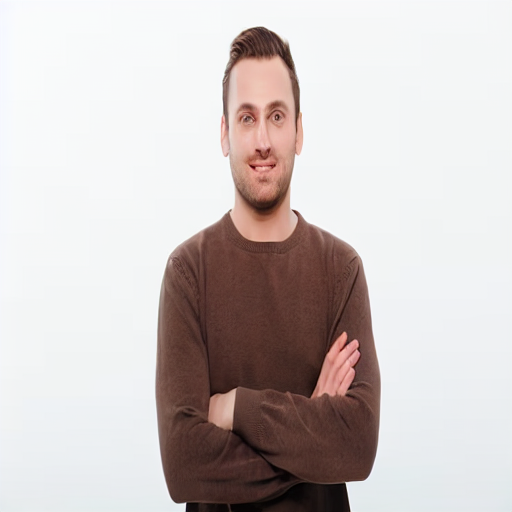


Saved to: /kaggle/working/protected_output.png


In [18]:
# =========================
# Kaggle Version
# =========================

from PIL import Image
import io
import os
from IPython.display import display
import time

# ---------------------------------
# STEP 1: Upload image to Kaggle
# ---------------------------------
# In Kaggle:
# Left Sidebar -> "Add Input"
# Upload your image manually
#
# Example uploaded path:
# /kaggle/input/my-images/photo.png
# ---------------------------------

image_path = "/kaggle/input/datasets/adilkhanm20/photos/male.avif"

# Load image
original = Image.open(image_path).convert("RGB")

print(f"Loaded: {os.path.basename(image_path)}")
print(f"Size: {original.size[0]}x{original.size[1]} px")

# ---------------------------------
# STEP 2: Run your immunization
# ---------------------------------

protected_img, results = run_immunization(original, strength=0.72)

print("\nDone!")
print(f"DRS             : {results['drs']}")
print(f"PSNR            : {results['psnr']} dB")
print(f"Attacks blocked : {results['attacks_blocked']}/{results['total_attacks']}")
print(f"Processing time : {results['processing_time']}s")

# ---------------------------------
# STEP 3: Display image
# ---------------------------------

display(protected_img)

# ---------------------------------
# STEP 4: Save output
# ---------------------------------

out_path = "/kaggle/working/protected_output.png"
protected_img.save(out_path)

print(f"\nSaved to: {out_path}")

# ---------------------------------
# STEP 5: Download file
# ---------------------------------
# In Kaggle:
# Right sidebar -> Output -> protected_output.png
# Click download
# ---------------------------------

In [ ]:
# ── 20. KAGGLE HTTP SERVER ─────────────────────────────────
# Exposes the immunization pipeline as a REST API via ngrok.
# Copy the printed URL into backend/.env as KAGGLE_URL=<url>

import threading
import base64
import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI, UploadFile, File
from fastapi.responses import JSONResponse
import uvicorn
from pyngrok import ngrok

# ── Set your ngrok auth token (free at https://dashboard.ngrok.com) ──
NGROK_TOKEN = `3DrEJRshRxTbkUGWwrhKp2NUbzY_vaGGZHFJD6xSWrjuLZrY`  # <-- paste your token here
ngrok.set_auth_token(NGROK_TOKEN)

server_app = FastAPI()

@server_app.get('/health')
def health():
    return {'status': 'ok'}

@server_app.post('/process')
async def process_endpoint(file: UploadFile = File(...)):
    img_bytes = await file.read()
    original = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    protected_img, results = run_immunization(original)
    buf = io.BytesIO()
    protected_img.save(buf, format='PNG')
    img_b64 = base64.b64encode(buf.getvalue()).decode()
    return JSONResponse({'protected_image_b64': img_b64, 'metrics': results})

# Start ngrok tunnel
public_url = ngrok.connect(8000)
print(f'Kaggle API URL: {public_url}')
print('Paste this URL into backend/.env as KAGGLE_URL=<url>')

# Start uvicorn in background thread
def _run_server():
    uvicorn.run(server_app, host='0.0.0.0', port=8000, log_level='warning')

t = threading.Thread(target=_run_server, daemon=True)
t.start()
print('Server started. Waiting for requests...')